### **INTRODUCCIÓN**

La segmentación de clientes es una de las aplicaciones más relevantes del aprendizaje no supervisado en el ámbito de la analítica de datos, ya que permite descubrir patrones de comportamiento ocultos sin necesidad de disponer de etiquetas predefinidas. Este tipo de análisis resulta especialmente útil en entornos empresariales donde los clientes presentan comportamientos heterogéneos y es necesario agruparlos para poder tomar decisiones más informadas.

En este proyecto se aborda el análisis de un conjunto de datos de clientes de un centro comercial con el objetivo de identificar grupos homogéneos en función de variables demográficas y de consumo. Para ello, se trabaja con técnicas de clustering, concretamente con los algoritmos K-Means y DBSCAN, que permiten obtener distintas perspectivas sobre la estructura de los datos.

El desarrollo del proyecto se basa en un flujo de trabajo estructurado mediante pipelines, que garantiza la correcta integración de las fases de preprocesamiento, transformación y modelado. Además, se incorporan técnicas de evaluación y validación como el análisis del coeficiente de silueta, la búsqueda de hiperparámetros y la visualización de clusters para comparar el comportamiento de los distintos modelos.

El objetivo final es obtener una segmentación de clientes interpretable y útil, que permita comprender mejor los distintos perfiles de comportamiento dentro del dataset y sirva como base para análisis posteriores orientados a la toma de decisiones.

### **DEFINICIÓN DEL PROBLEMA**

Las empresas, especialmente en sectores como el retail o los centros comerciales, necesitan entender cómo se comportan sus clientes para poder diseñar estrategias más eficaces. Sin una segmentación adecuada, todas las acciones de marketing se aplican de forma generalizada, lo que reduce su efectividad.

El problema principal es Identificar grupos homogéneos de clientes en función de sus características y comportamiento de gasto, con el fin de diseñar estrategias diferenciadas para cada segmento.

Por ejemplo, no es lo mismo un cliente con altos ingresos que gasta poco, que uno con ingresos medios pero alto nivel de consumo. Detectar estos perfiles permite:

* personalizar campañas de marketing
* optimizar promociones
* mejorar la fidelización
* aumentar ingresos

**Problema técnico** 

Desde el punto de vista técnico, este problema se aborda como un problema de aprendizaje no supervisado (clustering) cuyo objetivo es agrupar clientes en clusters en función de su similitud, sin conocer previamente las etiquetas.

**Objetivo del proyecto**

Por todo lo anteriormente mencionado, se establece, como objetivo principal, obtener una segmentación clara y útil de los clientes que permita interpretar distintos perfiles de comportamiento y aportar valor desde el punto de vista de negocio.

### **IMPORTAR LIBRERÍAS**

In [233]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.cluster import KMeans, DBSCAN


from sklearn.metrics import silhouette_score


import warnings
warnings.filterwarnings('ignore')

import joblib
import os

np.random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


### **1. CARGA DE DATOS Y EXPLORACIÓN INICIAL**

En primer lugar, se debe cargar el dataset y hacer una exploración preliminar para entender su estructura, la calidad de los datos y las posibles particularidades que puedan influir en el análisis posterior de clustering

In [7]:
def load_data(path):
    """
    Carga el dataset desde un fichero CSV
    
    Parámetros - path (str): ruta del archivo
    
    Devuelve - df (DataFrame): dataset cargado
    """
    df = pd.read_csv(path)
    
    print("Datos cargados correctamente")
    print(f"Shape: {df.shape}")
    
    return df

In [10]:
df = load_data("./data/Mall_Customers.csv")
df

Datos cargados correctamente
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


En esta fase inicial de exploración se ha analizado la estructura general del dataset con el objetivo de comprender su composición y evaluar su idoneidad para un problema de clustering.

El dataset está compuesto por 200 registros correspondientes a clientes de un centro comercial, junto con 5 variables. Cada observación representa un cliente individual identificado mediante CustomerID, acompañado de información demográfica y de comportamiento de consumo.

Una de las primeras conclusiones importantes es que el dataset no presenta valores nulos en ninguna de sus variables, lo que indica una calidad de datos alta y reduce la necesidad de realizar procesos de imputación o limpieza avanzada. Además, la estructura del dataset es sencilla y bien definida, lo que facilita su uso en técnicas de aprendizaje no supervisado.

En cuanto a los tipos de variables, se observa que cuatro de ellas son numéricas (Age, Annual Income, Spending Score y CustomerID) y una es categórica (Gender). Esto es adecuado para el análisis de clustering, ya que las variables numéricas permiten medir similitudes entre clientes de forma directa.

Finalmente, se identifica que CustomerID actúa únicamente como identificador único, por lo que no aporta información relevante para el modelo y deberá ser eliminada en fases posteriores del análisis.

### **2. MINIEDA**

La idea es comprobar las relaciones entre las variables para intentar observar alguna posible clusterizacion y así además seleccionar variables y por supuesto comprobar si hay que transformar y escalar 

**1. Exploración general**

In [13]:
def explore_data(df):
    print("Shape del dataset:")
    print(df.shape)
    
    print("\nTipos de datos:")
    print(df.dtypes)
    
    print("\nValores nulos:")
    print(df.isnull().sum())
    
    print("\nEstadísticas numéricas:")
    print(df.describe())
    
    print("\nVariables categóricas:")
    print(df.select_dtypes(include='object').nunique())

In [14]:
explore_data(df)

Shape del dataset:
(200, 5)

Tipos de datos:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Valores nulos:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Estadísticas numéricas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               

En la exploración general se ha analizado la consistencia de los datos, la presencia de valores nulos y la distribución de los tipos de variables.

Los resultados confirman que el dataset es completamente consistente, sin valores faltantes en ninguna de las columnas. Esto es especialmente positivo en un contexto de clustering, ya que evita sesgos o distorsiones en la medición de distancias entre observaciones.

En términos de estructura, el dataset está compuesto mayoritariamente por variables numéricas, lo que facilita la aplicación de algoritmos como K-Means y DBSCAN, que dependen de medidas de distancia.

La única variable categórica es Gender, con dos posibles valores, lo que indica que no existe una complejidad categórica elevada. Esto simplifica el preprocesamiento, ya que no será necesario aplicar técnicas complejas de encoding.

En conjunto, la exploración general confirma que el dataset es adecuado para técnicas de clustering desde el punto de vista estructural y de calidad de datos.

**2. Distribución de las variables**

In [15]:
def plot_distributions(df):
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    for col in numeric_cols:
        plt.figure()
        df[col].hist(bins=50)
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.show()

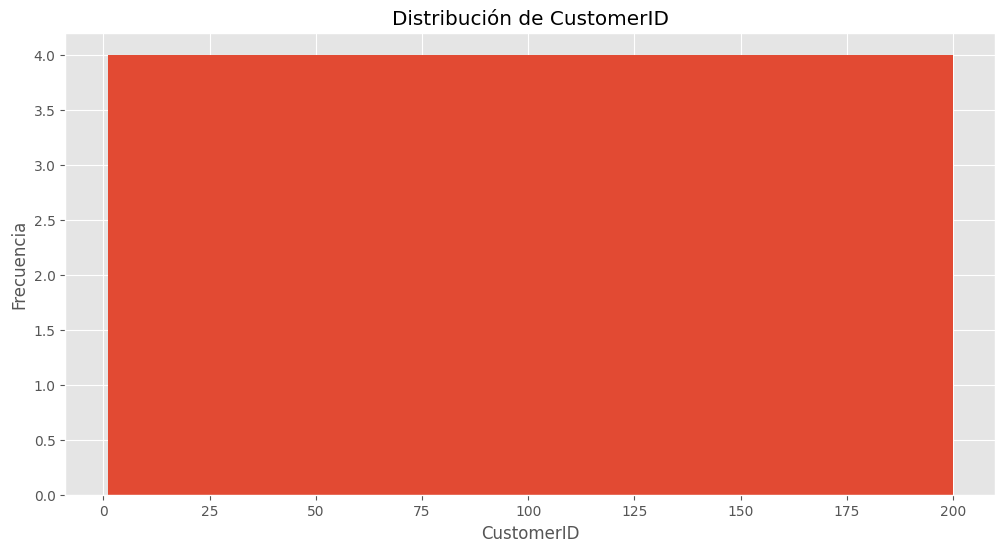

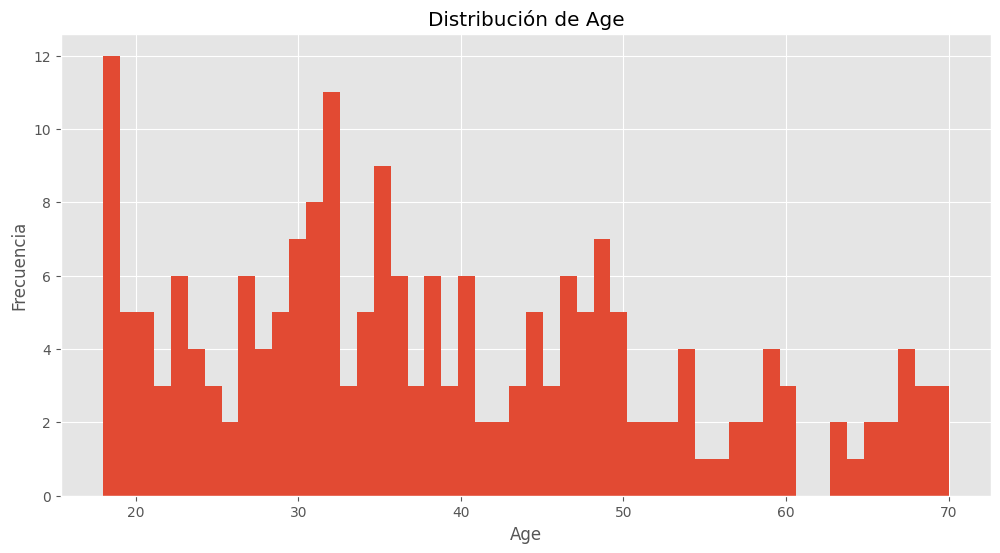

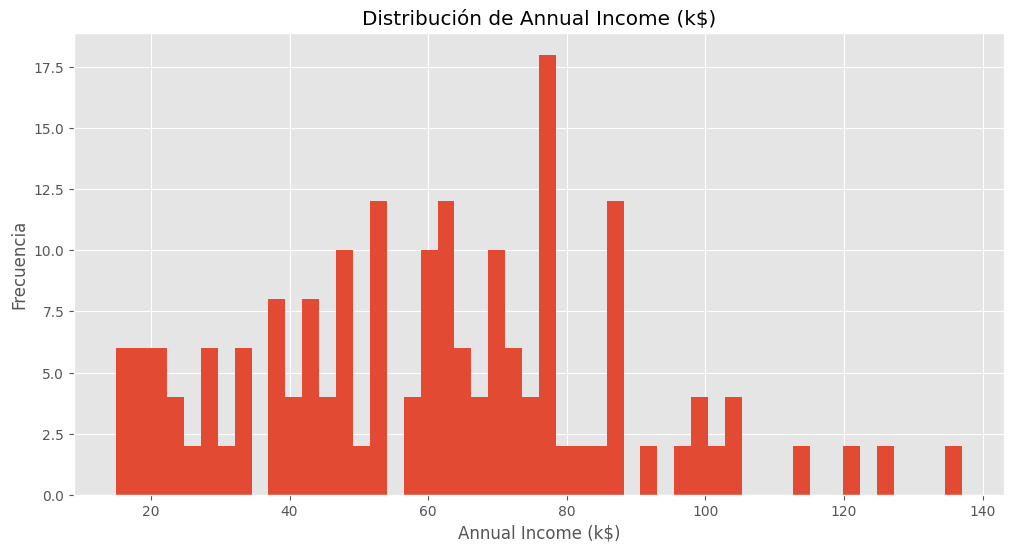

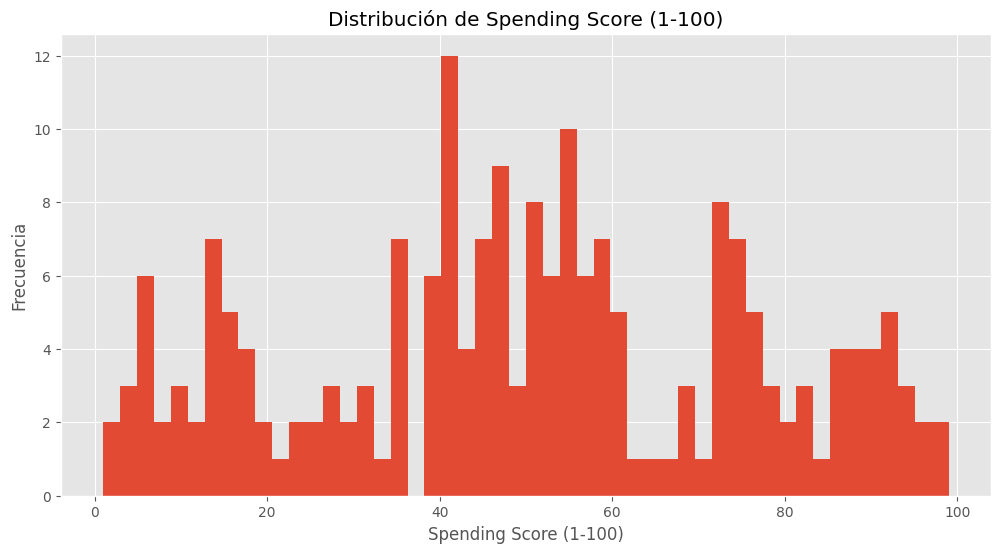

In [17]:
plot_distributions(df)

El análisis de la distribución de variables numéricas muestra que las tres variables principales (Age, Annual Income y Spending Score) presentan una dispersión significativa a lo largo de sus respectivos rangos.

La variable Age se distribuye entre 18 y 70 años, con una media cercana a los 39 años, lo que indica una población relativamente heterogénea en términos de edad.

El Annual Income presenta una variabilidad amplia, con valores que oscilan entre 15k dólares  y 137k dólares, y una media aproximada de 60k$. Esta amplitud sugiere la presencia de distintos niveles socioeconómicos dentro de los clientes, lo cual es un factor clave para la segmentación.

Por su parte, el Spending Score, que mide el comportamiento de gasto en una escala de 1 a 100, muestra una distribución equilibrada, sin concentraciones excesivas en un único rango. Esto indica que existen patrones de consumo diversos entre los clientes, lo cual es especialmente relevante para la identificación de clusters.

En conjunto, las distribuciones observadas no siguen una forma perfectamente normal, sino que presentan variabilidad suficiente como para sugerir la existencia de posibles agrupaciones naturales dentro de los datos.

**3. Comparaciones dos a dos**

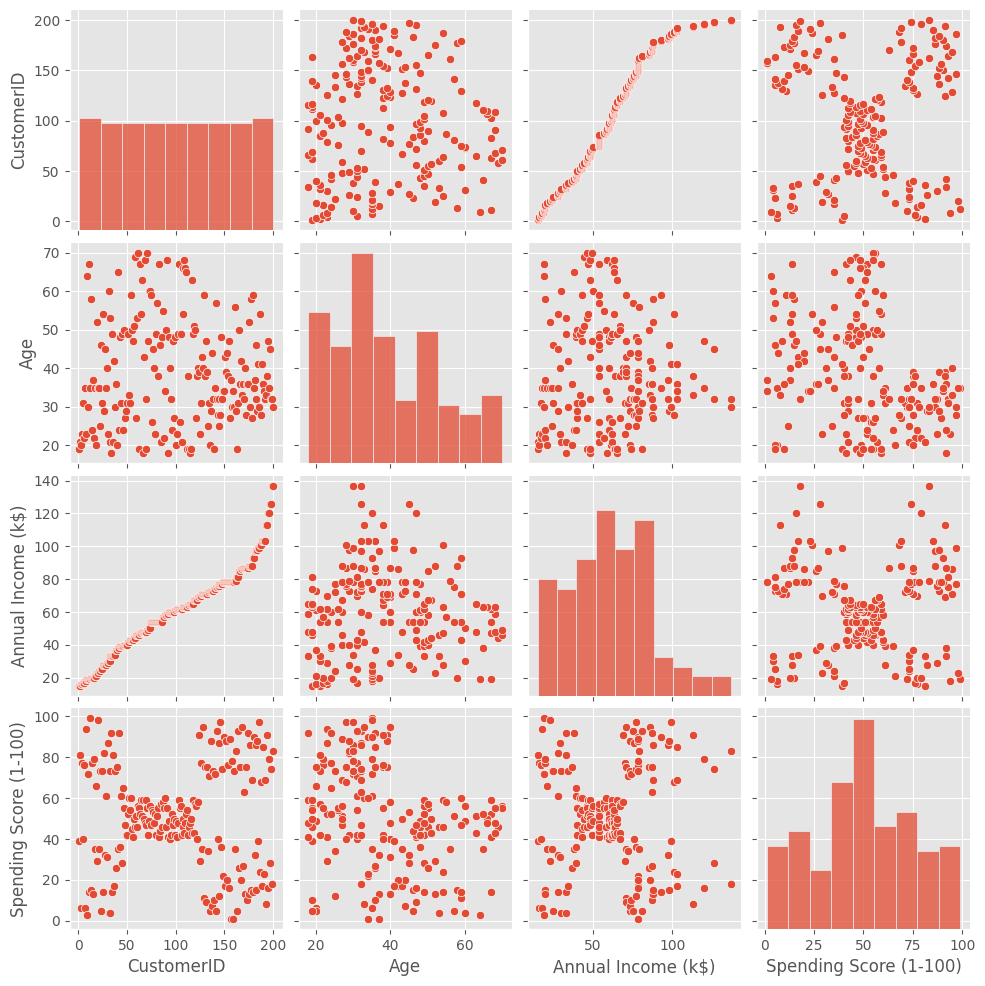

In [12]:
sns.pairplot(df)

El análisis conjunto mediante el pairplot permite observar de forma global las relaciones entre todas las variables numéricas del dataset.

En este gráfico se refuerza la idea de que no existen relaciones lineales fuertes entre las variables principales, especialmente entre edad, ingresos y Spending Score. Sin embargo, sí se observan agrupaciones visuales en ciertas zonas del espacio, especialmente en la relación entre ingresos y Spending Score, lo que sugiere la posible existencia de clusters naturales.

Por otro lado, la variable CustomerID no presenta ningún tipo de patrón relevante, lo cual confirma que no aporta información útil para el análisis y debe ser eliminada en las fases posteriores.

A primera vista, podríamos ver algún clúster tipo mancha (blobs) pero es interesante ver gráfico a gráfico las relaciones:

*Income vs Spending Score*

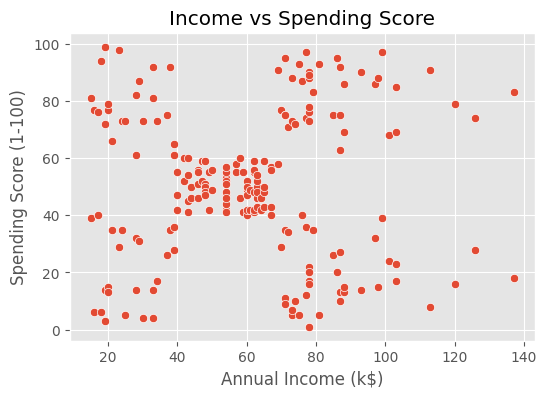

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Income vs Spending Score")
plt.show()

El gráfico que relaciona el ingreso anual con el Spending Score muestra una estructura claramente segmentada en varios grupos diferenciados. No se observa una relación lineal directa entre ambas variables, lo que indica que tener mayores ingresos no implica necesariamente un mayor nivel de gasto.

De hecho, se identifican patrones interesantes, como clientes con ingresos altos pero bajo nivel de gasto, así como clientes con ingresos medios o bajos pero con un alto Spending Score. Esta falta de correlación directa sugiere que el comportamiento de consumo depende de factores más complejos que el nivel de ingresos, lo cual es muy positivo desde el punto de vista del clustering, ya que favorece la aparición de grupos bien diferenciados.

En conjunto, esta relación es una de las más importantes del dataset, ya que parece contener una estructura natural de segmentación clara.

*Age vs Spending Score*

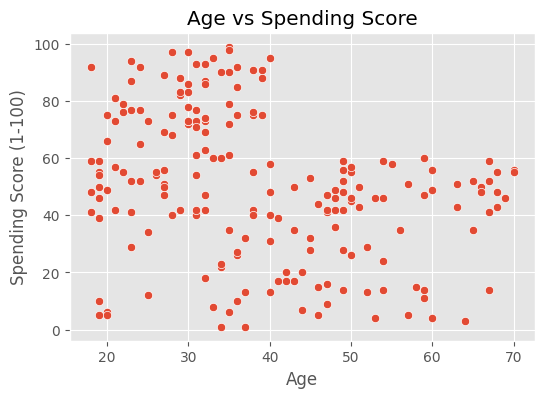

In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)")
plt.title("Age vs Spending Score")
plt.show()

En el análisis entre la edad y el Spending Score se observa una tendencia más difusa, sin una relación lineal evidente. Sin embargo, sí se pueden intuir ciertos patrones: los clientes más jóvenes tienden a presentar una mayor variabilidad en su comportamiento de gasto, mientras que los clientes de mayor edad tienden a concentrarse en valores más bajos o medios del Spending Score.

Esto sugiere que la edad puede influir parcialmente en el comportamiento de consumo, pero no de forma determinante. Por tanto, esta variable puede aportar información adicional al clustering, aunque no será la principal variable discriminante.

*Age vs Annual Income*

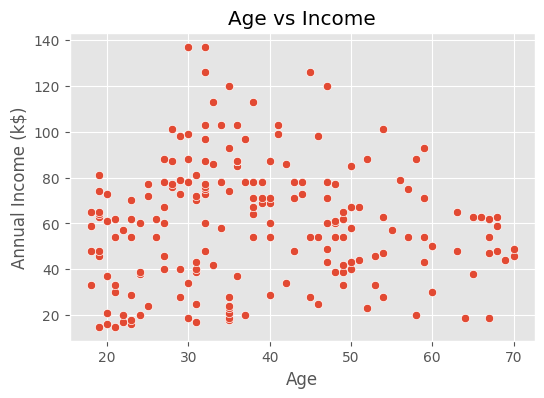

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="Annual Income (k$)")
plt.title("Age vs Income")
plt.show()

El análisis entre la edad y el ingreso anual no muestra una correlación clara. Los puntos están ampliamente dispersos, lo que indica que no existe una relación directa entre la edad del cliente y su nivel de ingresos dentro de este dataset.

Esto es importante porque implica que el ingreso es una variable independiente de la edad en este contexto, lo que aumenta su utilidad para la segmentación, ya que aporta información complementaria y no redundante.

### **3. PREPROCESAMIENTO Y TRANSFORMACIONES**

Dado que las variables presentan escalas heterogéneas, se tiene que aplicar una estandarización para garantizar que todas las variables contribuyan de forma equitativa al cálculo de distancias en los algoritmos de clustering.

Asimismo y, en base al minieda realizado, se debe:
* Eliminar la variable CustomerID (irrelevante)
* Gender: como es una variable categórica, aplicar el OneHotEncoder
* Las variables numéricas (Age, Annual Income, Spending Score) se deben escalar

In [175]:
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

base_pipeline = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ]
)

*Transformaciones para DBSCAN*

In [169]:
dbscan_transformer = Pipeline(steps=[
    ("preprocessing", base_pipeline)
])

### **4. MODELADO**

#### **K-Means**

*Transformación para búsqueda de K (sin PCA)*

In [128]:
kmeans_transform = Pipeline(steps=[
    ("preprocessing", base_pipeline)
])

*Búsqueda de K (Silhouette y Elbow)*

In [129]:
X_kmeans = kmeans_transform.fit_transform(df)

K_range = range(2, 10)
inertias = []
silhouettes = []

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_kmeans)
    
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_kmeans, labels))

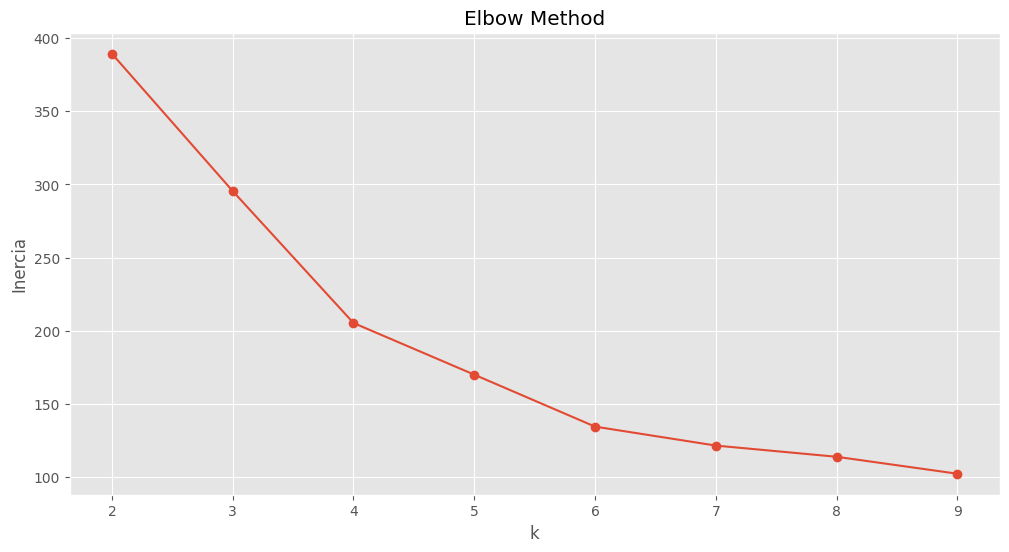

In [130]:
#Elbow
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

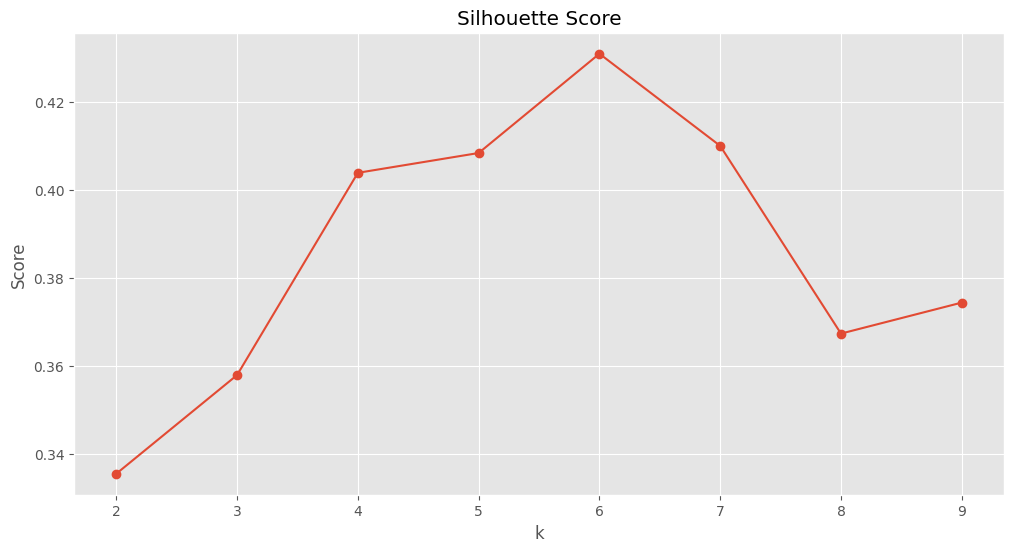

In [131]:
#Silhouette
plt.plot(K_range, silhouettes, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

In [152]:
best_k = 6

In [153]:
#Kmeans sin PCA
kmeans_pipeline = Pipeline(steps=[
    ("preprocessing", base_pipeline),
    ("model", KMeans(n_clusters=best_k, random_state=42))
])

In [155]:
# Entrenamiento
kmeans_pipeline.fit(df)

labels = kmeans_pipeline.named_steps["model"].labels_

In [156]:
# Validación
X_final = kmeans_pipeline[:-1].transform(df)

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_final, labels)

print("Silhouette final:", sil_score)

Silhouette final: 0.43106526216603014


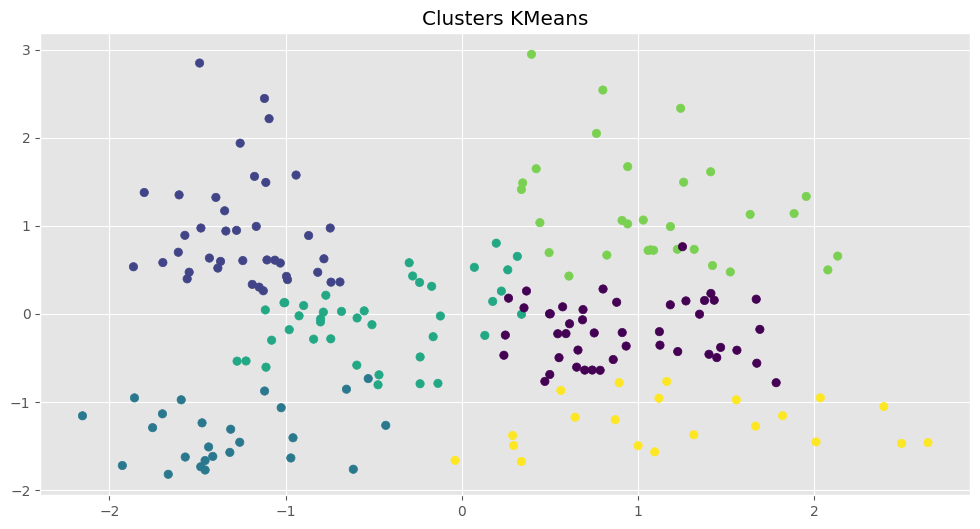

In [136]:
#Visualización
from sklearn.decomposition import PCA

X_vis = PCA(n_components=2).fit_transform(X_final)

plt.scatter(X_vis[:,0], X_vis[:,1], c=labels)
plt.title("Clusters KMeans")
plt.show()

In [137]:
#Análisis de clusters
df_clusters = df.copy()
df_clusters["cluster"] = labels

df_clusters.groupby("cluster")[num_cols].mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,56.333333,54.266667,49.066667
1,32.692308,86.538462,82.128205
2,25.560000,26.480000,76.240000
3,26.125000,59.425000,44.450000
4,44.000000,90.133333,17.933333
5,45.523810,26.285714,19.380952


El modelo K-Means aplicado al dataset de clientes del centro comercial ha permitido identificar una estructura clara de segmentación basada en tres variables fundamentales: la edad, el ingreso anual y el Spending Score, que representa el nivel de gasto del cliente. A través de este enfoque no supervisado, se han obtenido seis clusters diferenciados que reflejan patrones de comportamiento de consumo bastante interpretables desde un punto de vista de negocio.

En términos generales, el modelo ha conseguido separar a los clientes en grupos relativamente homogéneos dentro de cada cluster, aunque con cierto grado de solapamiento natural propio de este tipo de problemas reales. El valor de silhouette obtenido en torno a 0.43 indica una separación moderada entre los grupos, lo cual es habitual en problemas de segmentación de clientes donde las variables no generan fronteras perfectamente definidas. No obstante, este valor es suficientemente bueno como para considerar que los clusters capturan patrones reales de comportamiento y no ruido aleatorio.

Además, se ha observado que la aplicación de PCA no mejora la calidad del modelo, ya que el valor de silhouette era prácticamente idéntico, motivo por el cual ha sido eliminado del análisis. 

A partir del análisis de los centroides de los clusters, se pueden extraer conclusiones sobre los distintos perfiles de clientes:
* El Cluster 0 representa a clientes de edad avanzada, con ingresos medios y un nivel de gasto también medio. Este grupo refleja un comportamiento estable y equilibrado, sin grandes fluctuaciones en su consumo, lo que sugiere clientes fieles pero poco propensos a incrementos significativos en su gasto.

* El Cluster 1 se caracteriza por clientes relativamente jóvenes, con ingresos altos y un Spending Score también elevado. Este es probablemente el grupo más valioso para el negocio, ya que combina capacidad económica con alta propensión al consumo. Se trata de clientes activos, con alto valor estratégico y gran potencial para campañas premium o programas de fidelización exclusivos.

* El Cluster 2 está formado por clientes jóvenes con ingresos bajos pero un nivel de gasto sorprendentemente alto. Este comportamiento sugiere un perfil impulsivo, donde el consumo no está directamente alineado con el nivel de ingresos. Desde el punto de vista de marketing, este grupo es especialmente interesante porque responde bien a estrategias emocionales, promociones y estímulos de compra inmediatos.

* El Cluster 3 agrupa clientes jóvenes con ingresos medios y un nivel de gasto moderado. Se trata de un segmento intermedio, sin un comportamiento especialmente marcado, pero con potencial de evolución hacia otros clusters dependiendo de las estrategias comerciales aplicadas. Es un grupo importante desde el punto de vista de crecimiento futuro.

* El Cluster 4 presenta un perfil muy particular: clientes de edad media, con ingresos muy altos, pero con un nivel de gasto muy bajo. Este es un segmento clave desde el punto de vista estratégico, ya que representa clientes con alto poder adquisitivo pero baja conversión. Esto puede indicar un comportamiento conservador, falta de interés en la oferta actual o ausencia de estímulos adecuados. Es un grupo con gran potencial de monetización si se aplican estrategias de marketing adecuadas orientadas a valor y exclusividad.

* El Cluster 5 está compuesto por clientes de edad media-alta con ingresos bajos y un nivel de gasto también bajo. Este grupo representa el segmento más conservador y menos rentable del conjunto de clientes. Su comportamiento es estable pero limitado en términos de consumo, por lo que las estrategias más adecuadas suelen centrarse en promociones básicas y mantenimiento de la relación con el cliente más que en el crecimiento del gasto.

En conclusión, el modelo K-Means ha permitido identificar seis perfiles de clientes claramente diferenciados, lo que aporta un gran valor desde el punto de vista del negocio. A pesar de que la separación entre clusters no es perfecta, algo esperable en datos reales de comportamiento humano, la segmentación obtenida es coherente, interpretable y accionable. Esto permite diseñar estrategias de marketing diferenciadas según el tipo de cliente, optimizando tanto la fidelización como la rentabilidad. En conjunto, el modelo cumple adecuadamente su objetivo de transformar datos no estructurados en conocimiento útil para la toma de decisiones empresariales.

#### **DBSCAN**

In [225]:
def build_dbscan_pipeline(eps, min_samples):
    return Pipeline(steps=[
        ("transform", dbscan_transformer),
        ("model", DBSCAN(eps=eps, min_samples=min_samples))
    ])

In [229]:
experiments = {}

for min_samples in [3, 5, 6, 10]:
    print(f"Min_samples = {min_samples}")
    
    outlier_percent = []
    
    for eps in np.linspace(0.2, 1.2, 80):
        
        pipeline = build_dbscan_pipeline(eps, min_samples)
        
        pipeline.fit(df)
        
        labels = pipeline.named_steps["model"].labels_
        
        perc_outliers = 100 * np.sum(labels == -1) / len(labels)
        outlier_percent.append(perc_outliers)
    
    experiments[min_samples] = outlier_percent

Min_samples = 3
Min_samples = 5
Min_samples = 6
Min_samples = 10


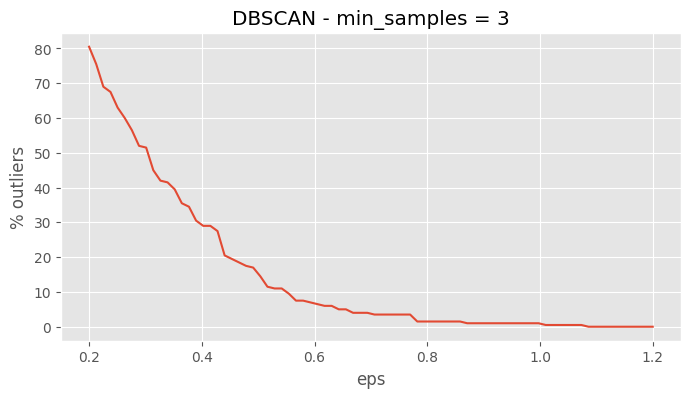

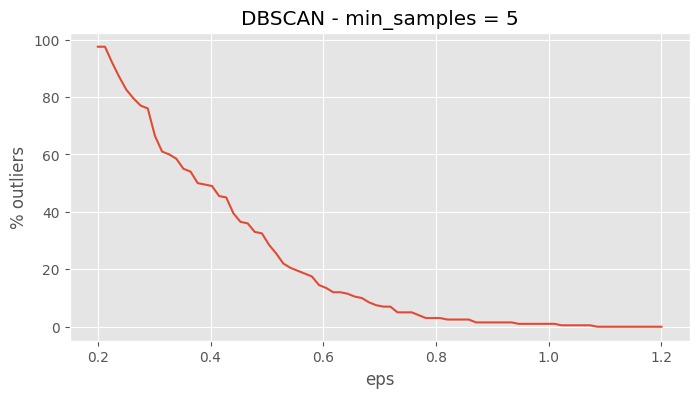

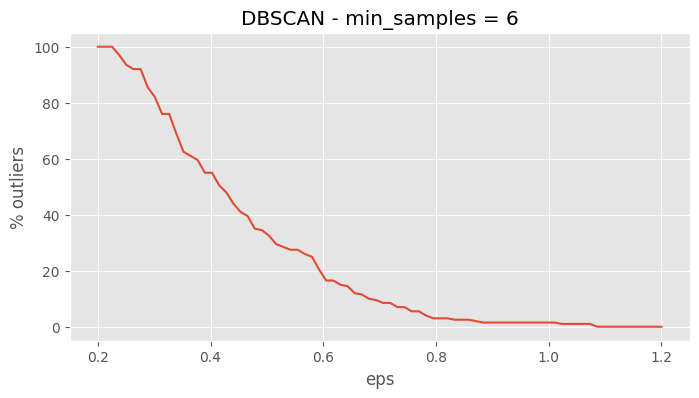

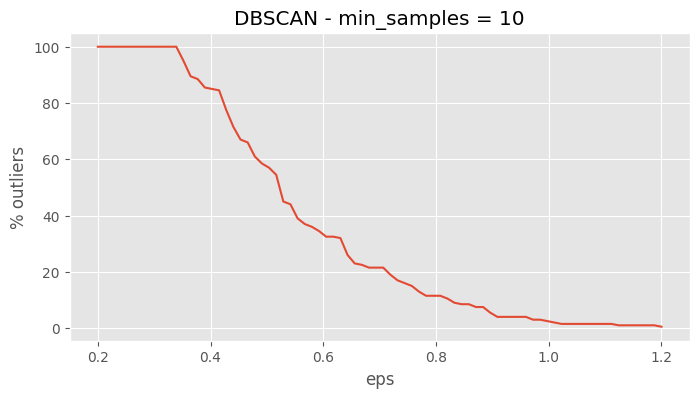

In [230]:
#Visualización
eps_values = np.linspace(0.2, 1.2, 80)

for min_samples in [3, 5, 6, 10]:
    
    plt.figure(figsize=(8,4))
    
    sns.lineplot(
        x=eps_values,
        y=experiments[min_samples]
    )
    
    plt.title(f"DBSCAN - min_samples = {min_samples}")
    plt.xlabel("eps")
    plt.ylabel("% outliers")
    plt.show()

In [234]:
#Modelado
final_pipeline = build_dbscan_pipeline(
    eps=0.6,  
    min_samples=6
)

final_pipeline.fit(df)

labels_dbscan = final_pipeline.named_steps["model"].labels_

In [216]:
#Clusters
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

print("Clusters detectados:", n_clusters)

Clusters detectados: 5


In [217]:
#Outliers
outliers = np.sum(labels_dbscan == -1)
print("Outliers:", outliers)
print("Porcentaje:", 100 * outliers / len(labels_dbscan))

Outliers: 34
Porcentaje: 17.0


In [219]:
#Labels
df_dbscan = df.copy()
df_dbscan["cluster"] = labels_dbscan

In [220]:
#Clusters
df_dbscan.groupby("cluster")[num_cols].mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
-1,38.558824,71.558824,32.735294
0,39.580952,49.038095,53.885714
1,37.600000,29.000000,28.800000
2,50.500000,29.750000,9.250000
3,32.588235,81.647059,82.558824
4,44.722222,82.777778,15.611111


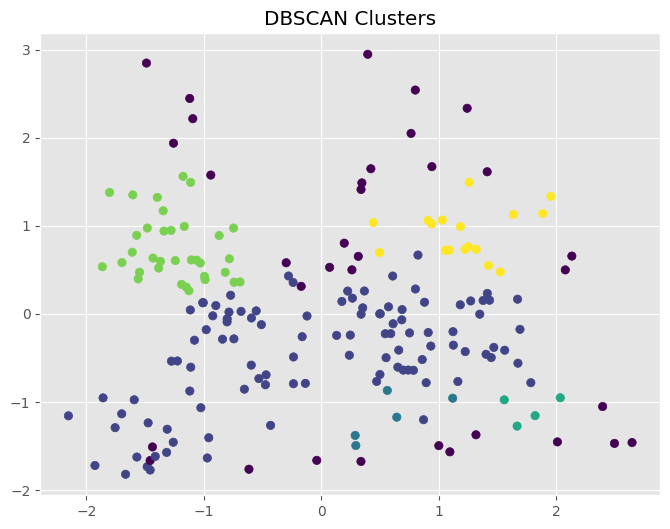

In [221]:
#Visualización
X_transformed = final_pipeline.named_steps["transform"].transform(df)

X_vis = PCA(n_components=2).fit_transform(X_transformed)

plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels_dbscan)
plt.title("DBSCAN Clusters")
plt.show()

.

El modelo DBSCAN aplicado al dataset de clientes ha permitido obtener una segmentación basada en densidad que complementa el análisis realizado previamente con K-Means. A diferencia de este último, DBSCAN no obliga a todos los puntos a pertenecer a un cluster, lo que introduce una dimensión adicional muy relevante: la identificación de clientes que no encajan claramente en ningún patrón homogéneo.

Tras la calibración de los hiperparámetros, se ha seleccionado una configuración con eps = 0.6 y min_samples = 6, que ha permitido obtener un total de cinco clusters diferenciados junto con un 17% de observaciones clasificadas como ruido. Este resultado es especialmente relevante porque indica que el espacio de datos no presenta una estructura completamente compacta ni perfectamente separable, sino que existe una combinación de grupos bien definidos y observaciones intermedias o atípicas.

Al analizar las medias de las variables dentro de cada cluster, se pueden identificar claramente distintos perfiles de clientes con comportamientos de consumo diferenciados.

* Uno de los grupos más relevantes es el formado por clientes jóvenes con ingresos altos y un nivel de gasto elevado. Este segmento representa el perfil más atractivo desde el punto de vista comercial, ya que combina capacidad económica con alta propensión al consumo. Se trata de clientes que probablemente responden bien a estrategias de marketing directo, promociones personalizadas o programas de fidelización premium.

* En contraste, aparece un grupo de clientes con ingresos elevados pero un nivel de gasto bajo. Este segmento es particularmente interesante porque representa una oportunidad de negocio no explotada. Son clientes con capacidad adquisitiva pero que no están realizando un consumo proporcional a sus ingresos, lo que sugiere que podrían ser sensibles a estrategias de activación, ofertas personalizadas o cambios en la propuesta de valor.

* Otro grupo identificado corresponde a clientes con ingresos y gasto bajos. Este segmento refleja un perfil de bajo valor comercial, con un comportamiento de consumo limitado y menor impacto en la rentabilidad global. Desde una perspectiva de negocio, este grupo suele requerir estrategias de bajo coste o automatizadas, ya que su retorno potencial es reducido.

* También se observa un cluster de clientes con características intermedias, tanto en ingresos como en nivel de gasto. Este grupo representa un segmento más estable y equilibrado, sin comportamientos extremos, y suele corresponder a la base estándar de clientes. Aunque no destaca por alto valor individual, puede ser relevante por volumen.

Finalmente, el modelo identifica un conjunto de observaciones clasificadas como ruido. Este grupo no presenta un patrón de comportamiento suficientemente consistente como para ser asignado a un cluster concreto. En términos de negocio, estos clientes pueden interpretarse como perfiles híbridos o atípicos, con comportamientos que no encajan en ninguna de las estructuras principales detectadas. Este resultado es una de las principales ventajas de DBSCAN frente a K-Means, ya que permite capturar la heterogeneidad del comportamiento del cliente sin forzar su asignación a un segmento artificial.

#### **4.1 COMPARATIVA DE CLUSTERS**

**K-Means**

El modelo K-Means ha permitido obtener una segmentación clara y relativamente equilibrada de los clientes, identificando grupos bien definidos en función de variables como la edad, el ingreso anual y el spending score. Una de las principales características de este enfoque es que fuerza la asignación de todos los clientes a un cluster, lo que garantiza una segmentación completa del dataset sin observaciones sin clasificar.

En este caso, K-Means ha mostrado una buena capacidad para identificar perfiles de negocio fácilmente interpretables, como clientes de alto ingreso y alto consumo, clientes de bajo ingreso y bajo consumo, o perfiles intermedios. Además, los clusters obtenidos presentan una coherencia interna adecuada, lo que se refleja en valores de silueta aceptables y en la estabilidad de los resultados.

Sin embargo, esta misma fortaleza implica también una limitación: K-Means asume que todos los clusters tienen forma aproximadamente esférica y tamaños similares, lo que puede simplificar en exceso la estructura real de los datos. Además, no tiene capacidad para identificar outliers o clientes que no encajan claramente en ningún grupo.

**DBSCAN**

Por otro lado, DBSCAN ha aportado una visión más flexible y realista de la distribución de los clientes. Este algoritmo no fuerza la asignación de todos los puntos a un cluster, sino que identifica regiones de alta densidad separadas por zonas de menor densidad, lo que permite capturar estructuras más complejas.

En el modelo final, DBSCAN ha identificado cinco clusters junto con aproximadamente un 17% de observaciones etiquetadas como ruido. Este resultado es especialmente relevante, ya que introduce una dimensión adicional al análisis: la existencia de clientes que no pertenecen claramente a ningún segmento homogéneo.

Estos clientes considerados como ruido pueden interpretarse como perfiles intermedios, atípicos o con comportamientos mixtos, lo cual no es capturable por K-Means. Además, DBSCAN ha permitido identificar clusters con perfiles muy diferenciados, como clientes de alto ingreso y alto gasto, o clientes con alto ingreso pero bajo nivel de consumo, que representan oportunidades de negocio especialmente interesantes.

No obstante, DBSCAN también presenta limitaciones en este contexto. Su rendimiento es altamente sensible a la elección de hiperparámetros, especialmente eps y min_samples, y en datasets como este, donde las transiciones entre grupos son suaves, puede generar una cantidad relativamente alta de ruido o clusters menos estables.

### **CONCLUSIONES**

#### **Conclusión general**

En este proyecto se ha abordado el problema de segmentación de clientes desde un enfoque de aprendizaje no supervisado, aplicando dos algoritmos de clustering complementarios: K-Means y DBSCAN, ambos implementados mediante pipelines para garantizar la reproducibilidad y la correcta integración del preprocesamiento.

El análisis exploratorio inicial permitió confirmar que el dataset presenta una buena calidad de datos, sin valores nulos y con variables numéricas adecuadas para técnicas basadas en distancia. A partir de este punto, se diseñó un flujo de trabajo estructurado que incluyó escalado de variables y evaluación sistemática de hiperparámetros.

En el caso de K-Means, se obtuvo una segmentación estable y coherente, con una estructura clara de clusters y un valor de silueta adecuado, lo que indica una separación razonable entre grupos. Este modelo demostró ser especialmente útil para generar una segmentación global del conjunto de clientes, con perfiles fácilmente interpretables.

Por otro lado, DBSCAN aportó una visión más flexible de la estructura de los datos, permitiendo identificar clusters basados en densidad y detectando explícitamente un conjunto de clientes considerados como ruido. Aunque su comportamiento fue más sensible a los hiperparámetros, permitió capturar matices que K-Means no es capaz de modelar, especialmente en lo relativo a clientes atípicos o fronterizos.

En conjunto, ambos modelos han demostrado ser complementarios: K-Means proporciona una segmentación estructurada y estable, mientras que DBSCAN añade una capa adicional de profundidad al identificar heterogeneidad dentro de los datos.

#### **Conclusión de negocio**

Desde una perspectiva de negocio, los resultados obtenidos permiten segmentar la base de clientes en grupos claramente diferenciados con implicaciones directas para la toma de decisiones estratégicas.

Se identifican, en primer lugar, clientes de alto valor, caracterizados por un alto nivel de ingresos y un elevado nivel de gasto. Este segmento representa el principal objetivo de las estrategias de fidelización, ya que concentra una alta rentabilidad y una elevada predisposición al consumo.

En segundo lugar, aparecen clientes con alto poder adquisitivo pero bajo nivel de gasto. Este grupo representa una oportunidad clave de crecimiento, ya que existe un potencial no explotado que puede ser activado mediante campañas de marketing personalizadas, mejoras en la propuesta de valor o estrategias de cross-selling.

También se identifican clientes de bajo valor, con ingresos y gasto reducidos, que tienden a aportar menos valor directo al negocio. Este segmento puede ser gestionado mediante estrategias automatizadas o de bajo coste, evitando inversiones excesivas en acciones de alto impacto.

Por último, DBSCAN permite identificar un conjunto de clientes no asignados a clusters claros, lo que sugiere la existencia de comportamientos atípicos o mixtos. Este grupo es especialmente interesante desde el punto de vista analítico, ya que puede contener oportunidades ocultas o patrones de consumo no evidentes bajo modelos tradicionales.

En conclusión, la combinación de ambos enfoques de clustering permite no solo segmentar la base de clientes de forma efectiva, sino también comprender mejor la diversidad de comportamientos dentro del conjunto de datos, facilitando la toma de decisiones estratégicas más precisas y orientadas al valor.

*Recomendaciones de negocio*

En primer lugar, se identifica un segmento de clientes de alto valor caracterizado por ingresos elevados y un nivel de gasto también alto. Este grupo representa el núcleo más rentable del negocio, por lo que se recomienda priorizar acciones de fidelización, programas VIP y estrategias de personalización avanzada. Mantener la satisfacción de estos clientes debe ser una prioridad, ya que su pérdida tendría un impacto directo significativo en los ingresos.

Por otro lado, existe un grupo de clientes con alto poder adquisitivo pero bajo nivel de gasto. Este segmento es especialmente interesante desde el punto de vista estratégico, ya que representa una oportunidad clara de crecimiento. Se recomienda diseñar campañas específicas orientadas a la activación del consumo, como ofertas personalizadas, recomendaciones basadas en comportamiento o incentivos al uso de servicios premium. El objetivo en este caso no es retener, sino incrementar el gasto medio por cliente.

También se ha identificado un segmento de clientes con bajos ingresos y bajo nivel de gasto, que aporta un valor reducido en términos de rentabilidad directa. En este caso, se recomienda adoptar estrategias de bajo coste, basadas en automatización y comunicación masiva, evitando inversiones excesivas en acciones personalizadas. Sin embargo, este grupo puede ser relevante en términos de volumen, por lo que no debe ser completamente ignorado.

Adicionalmente, el modelo DBSCAN ha permitido identificar un conjunto de clientes no asignados a clusters claros, lo que sugiere la presencia de comportamientos atípicos o mixtos. Este grupo puede ser especialmente útil para análisis más profundos, ya que podría contener clientes con patrones emergentes o con necesidades no cubiertas por las estrategias actuales. Se recomienda realizar un seguimiento más detallado de este segmento para detectar posibles oportunidades ocultas.

Finalmente, en términos generales, se recomienda utilizar K-Means como herramienta principal de segmentación operativa, debido a su estabilidad e interpretabilidad, mientras que DBSCAN debe considerarse como un complemento analítico que permite identificar casos extremos y enriquecer la comprensión del comportamiento del cliente.